# Cross integration

**Cross integration** combines batches that all measure the **same** modalities; the task is removing batch effects while keeping the biological structure. Reference dataset: `D52` (23,478 cells).

## 1. Install

`pip install multibench-sc` is all this notebook needs. Methods run in their own environments, downloaded only when you set `INSTALL_ENVS = True` (Linux or Colab).

<details>
<summary>Details</summary>

**Default.** With `INSTALL_ENVS = False` no environment is downloaded, only the reference data and stand-in outputs. Every cell runs; a method cell uses those outputs instead.

**Running methods.** Set `INSTALL_ENVS = True` on Colab or a Linux machine to download the prebuilt environments (no conda needed) and run the methods.

**On Colab**, choose a GPU runtime first (Runtime -> Change runtime type -> T4 GPU). On a CPU runtime the smaller CPU builds are installed and training methods are much slower.

</details>

In [1]:
import importlib.metadata, importlib.util, sys
if importlib.util.find_spec("multibench") is None:
    # keep the numpy / pandas this interpreter already has
    pins = [f"{p}=={importlib.metadata.version(p)}" for p in ("numpy", "pandas") if importlib.util.find_spec(p)]
    !{sys.executable} -m pip -q install "multibench-sc>=0.3" {" ".join(pins)}
    importlib.invalidate_caches()
    if importlib.util.find_spec("multibench") is None:        # not on PyPI: install from GitHub
        !{sys.executable} -m pip -q install "git+https://github.com/DSichang/scMultiBench.git" {" ".join(pins)}
else:
    print("multibench already installed")

multibench already installed


In [2]:
# False: no environment is downloaded; method cells use stand-in results.
# True (Linux or Colab): run the methods here; no conda needed.
# 2 envs, 1.4 GB to download on a CPU host, 3.0 GB on a GPU host.
INSTALL_ENVS = False

In [3]:
%matplotlib inline
import warnings
from pathlib import Path
import anndata
import pandas as pd
from tqdm import TqdmWarning
for _w in (FutureWarning, DeprecationWarning, pd.errors.PerformanceWarning,
           anndata.ImplicitModificationWarning, TqdmWarning):   # library warnings only; multibench's own stay visible
    warnings.filterwarnings("ignore", category=_w)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D52"
CATEGORY = "cross"
mtb.data.fetch('D52')   # the reference data (179 MB), downloaded once
print("multibench", mtb.__version__)

multibench 0.3.1


## 2. Run the analysis

### Environments - only if you will run methods

Installs the environments for UINMF, sciPENN and StabMap (2 envs, 1.4 GB to download on a CPU host, 3.0 GB on a GPU host). The cell skips the download unless `INSTALL_ENVS = True` on Linux.

<details>
<summary>Details</summary>

**Location.** Environments are unpacked under `mtb.config.DEFAULT.envs_dir` (`~/.cache/multibench/envs` on a host without conda); set it before this cell to use another disk. Environments already there are skipped.

**All cross methods.** `multibench env install --category cross --packed --run` installs every cross environment (7 envs, 11.1 GB to download on a CPU host, 17.0 GB on a GPU host); `multibench env plan --category cross` lists the size of each.

</details>

In [4]:
import sys
if not INSTALL_ENVS:
    print("INSTALL_ENVS is False - no environment is downloaded")
elif sys.platform != "linux":
    print("method environments are linux-64 archives - skipped on", sys.platform)
else:
    plan = mtb.env.install(['UINMF', 'sciPENN', 'StabMap'], category=CATEGORY)              # dry run: sizes only
    todo = [r for r in plan if not r["exists"]]
    print(f"{len(todo)} of {len(plan)} envs to download, {sum(r['archive_bytes'] or 0 for r in todo) / 1e9:.1f} GB")
    for r in mtb.env.install(['UINMF', 'sciPENN', 'StabMap'], category=CATEGORY, packed=True, dry_run=False):
        print(f"{r['env']:20s} {r['state']}")

INSTALL_ENVS is False - no environment is downloaded


### Run the methods

`run_all` runs UINMF, sciPENN and StabMap on `D52`, each in its own environment, and scores each embedding with scIB metrics. Without environments, the cell prints one line and loads stand-in results.

<details>
<summary>Details</summary>

**Stand-in.** When none of these environments is installed, the cell downloads the benchmark host's `run_all` outputs for `D52` with `mtb.data.fetch_outputs` (embeddings and run times included) and reloads them with `mtb.load_batch`.

**Offline fallback.** If that download fails, the cell uses the stored results (`load_results(source="rerun")`): `status` reads `STORED`, and there is no embedding to score.

**UINMF** uses batches 1 and 2 only, so its `emb_shape` counts fewer cells and its metrics cover those cells.

</details>

In [5]:
def stored_sweep(dataset, methods=None):
    """The stored results for `dataset`, as the object `run_all` returns."""
    long = mtb.load_results(CATEGORY, dataset=dataset, source="rerun", methods=methods)
    recs = [{"method": m, "status": "STORED", "metrics": g.set_index("metric")["value"].to_dict()}
            for m, g in long.groupby("method")]
    return mtb.BatchResult(recs, dataset, CATEGORY)

def stand_in(dataset, methods, stored):
    """The benchmark host's run_all outputs for `dataset`; the stored results if that download fails."""
    try:
        res = mtb.load_batch(mtb.data.fetch_outputs(dataset), methods=methods)
        print(f"stand-in: the benchmark host's run_all outputs for {dataset} (fetch_outputs) - real embeddings and run times")
        return res
    except Exception as e:                                   # offline, or the outputs are not published yet
        print(f"stand-in: the package's stored metric table ({type(e).__name__} from fetch_outputs: {e})")
        return stored_sweep(*stored)

check = mtb.scan("D52", CATEGORY, methods=['UINMF', 'sciPENN', 'StabMap'])
if check.env_ok.any():
    res = mtb.run_all("D52", CATEGORY,
                      methods=['UINMF', 'sciPENN', 'StabMap'],
                      out_dir="/tmp/tutorial_cross")
else:
    print("no method environment on this host - the run is skipped; a stand-in computed elsewhere covers it")
    res = stand_in("D52", ['UINMF', 'sciPENN', 'StabMap'], stored=("D52", ['UINMF', 'sciPENN', 'StabMap']))
res.summary

[scan] files OK for 3/3 method rows; 0/3 envs installed


no method environment on this host - the run is skipped; a stand-in computed elsewhere covers it
stand-in: the benchmark host's run_all outputs for D52 (fetch_outputs) - real embeddings and run times


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,StabMap,CHAIN_OK,49.4,embedding,"[23478, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8400,file_of_origin,3,0.6880,0.7760,0.5569,0.5656,0.6811,0.9940,0.9241,0.9313,0.5208,None
1,UINMF,CHAIN_OK,54.3,embedding,"[14764, 30]",0,cty1.csv+cty2.csv,0.9996,file_of_origin,2,0.6905,0.7772,0.5668,0.5553,0.6639,0.9933,0.9353,0.9296,0.8664,None
2,sciPENN,CHAIN_OK,44.0,embedding,"[23478, 512]",0,cty1.csv+cty2.csv+cty3.csv,0.8050,file_of_origin,3,0.7229,0.7960,0.6062,0.6226,0.7481,0.9978,0.8821,0.9277,0.3889,None


### Score one embedding

`run_all` has already scored every method. To score one embedding yourself, pass the file the method wrote and the dataset's label files to `mtb.evaluate`:

<details>
<summary>Details</summary>

**Label order.** `label_order=` passes the order in which the method stacked its cells, taken from the run record's `labels_used`.

**Choosing metrics.** `metrics=` accepts:

- `None` (the default): every applicable metric
- `"clustering"`, `"batch"` or `"all"`: a family
- a list such as `["ARI", "NMI"]`: those metrics

Batch metrics need `batch=` or several label files.

</details>

In [6]:
m, emb = "StabMap", None
if res.out_dir is not None:
    emb = Path(res.out_dir) / f"{m}_{res.dataset}" / "embedding.h5"
if emb is None or not emb.is_file():
    print(f"no embedding on this host for {m} - nothing to score")
    scores = None
else:
    rec = next(r for r in res.results if r["method"] == m)
    order = [Path(f).stem for f in rec.get("labels_used") or []] or None    # label files in the method's cell order
    scores = mtb.evaluate(emb, labels=mtb.labels_for(res.dataset), label_order=order, verbose=False)
scores.T if scores is not None else None

,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI
Value,0.683513,0.785017,0.556898,0.565587,0.683274,0.993936,0.9241,0.93265,0.520058


### Plot

`res.plot()` draws a bubble table. Circle size is the method's rank in each column (largest = best); colour is the metric value, scaled within the column (darker = higher).

<details>
<summary>Details</summary>

**Columns.** Metrics are grouped by family: blue for dimension reduction and clustering, green for batch correction. Each family starts with an **Overall** bar; its length and colour both show the family score.

</details>

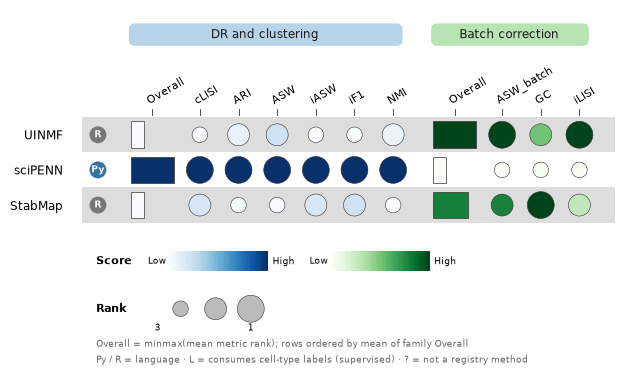

In [7]:
res.plot()

## 3. Your own data

The same calls on a dataset folder the package has not seen. `describe_layout` prints the files a cross dataset needs and their format:

In [8]:
print(mtb.describe_layout(CATEGORY))

Put your files in  <data_path>/<DATASET_NAME>/ , e.g. ./data/MYDATA/
  (dataset = the folder name; data_path = the folder that contains it)

LAYOUT FOR CROSS:
  rna1.h5 rna2.h5 rna3.h5 + adt1.h5 adt2.h5 adt3.h5
  cty1.csv cty2.csv cty3.csv          <- one per batch

  (numbered files live in the same flat dir; there is no batch column)

Modality roles and the filenames they resolve to:
    rna              rna.h5      - gene expression
    adt              adt.h5      - surface protein (CITE-seq antibody-derived tags)
    atac             atac.h5     - chromatin accessibility
    atac_gas         atac.h5     - ATAC as gene-activity scores  <-- note: plain atac.h5
    atac_peak        peak.h5     - ATAC as peaks                 <-- note: peak.h5, not atac.h5
    rna1/rna2/...    rna1.h5, rna2.h5, ... - one file per batch (mosaic/cross)
    adt1/adt2/...    adt1.h5, adt2.h5, ... - one file per batch (mosaic/cross)
    cty              cty.csv     - cell-type labels, one label set (vertic

`labels_for` returns a dataset's label files: `cty1`, `cty2`, ... in that order. Some methods stack their cells in another order; `labels_for(DATASET, CATEGORY, method)` returns the files in that method's order. A wrong order gives wrong scores without an error.

<details>
<summary>Details: label order</summary>

**On `D52`**, `labels_for` returns another order for StabMap (`cty3, cty1, cty2`).

**With `evaluate`.** Pass the dict `labels_for` returns as is. A dict you build or reorder yourself goes in as is only in the default order; name any other order with `label_order=`.

**Check.** `run_all` scores every order that fits the cell count and keeps the one with the highest ARI; the `label_order` column of `res.summary` shows it.

</details>

In [9]:
labels = mtb.labels_for(DATASET)            # {file stem: path}
print({k: Path(v).name for k, v in labels.items()})
print(*Path(next(iter(labels.values()))).read_text().splitlines()[:4], sep="\n")
print("StabMap:", list(mtb.labels_for(DATASET, CATEGORY, "StabMap")))

{'cty1': 'cty1.csv', 'cty2': 'cty2.csv', 'cty3': 'cty3.csv'}
"x"
"CD4 memory"
"CD8 naive"
"CD4 memory"
StabMap: ['cty3', 'cty1', 'cty2']


`mtb.io.export_dataset` with `batch=` writes one numbered set of files per batch, here from a synthetic AnnData:

In [10]:
import anndata as ad, numpy as np, tempfile, os
rng = np.random.default_rng(0)
demo = ad.AnnData(X=rng.poisson(1.0, size=(150, 40)).astype(float))            # RNA, cells x genes
demo.var_names = [f"gene{i}" for i in range(40)]
demo.obsm["protein"] = rng.poisson(3.0, size=(150, 12)).astype(float)          # ADT
demo.uns["protein_names"] = [f"CD{i}" for i in range(12)]
demo.obs["celltype"] = rng.choice(["T", "B", "NK"], 150)
demo.obs["batch"]    = rng.choice(["donor1", "donor2", "donor3"], 150)

folder = mtb.io.export_dataset(demo, os.path.join(tempfile.mkdtemp(), "MYCROSS"),
                               rna="X", adt="obsm:protein", labels="obs:celltype",
                               batch="obs:batch")
print(sorted(os.listdir(folder)))
sc = mtb.scan("MYCROSS", CATEGORY, data_path=folder.parent)
print(f"{int(sc.files_ok.sum())} of {len(sc)} method variants pass the file check")

['adt1.h5', 'adt2.h5', 'adt3.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5', 'rna3.h5']
[scan] files OK for 8/8 method rows; 0/8 envs installed


8 of 8 method variants pass the file check


A real dataset under a new name: a random 60% of `D52`'s cells, capped at 2,000 cells and 5,000 features per file.

<details>
<summary>Details: cell alignment</summary>

**Alignment.** Files with the same number of cells keep the same cells in the same order, so each modality file stays aligned with its label file. An export of your own data must keep this alignment.

</details>

In [11]:
import os
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0, max_cells=2000, max_features=5000):
    """Copy a dataset under a new name, keeping a random `frac` of its cells; files with the same cell count keep the same cells."""
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    counts[fn] = f["matrix/data"].shape[1]   # features x cells
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = min(max(50, int(n * frac)), max_cells)
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                n_feat = f["matrix/data"].shape[0]
                fidx = np.arange(n_feat) if n_feat <= max_features else np.sort(rng.choice(n_feat, size=max_features, replace=False))
                block = f["matrix/data"][fidx, :] if n_feat > max_features else f["matrix/data"][()]
                grp.create_dataset("data", data=np.asarray(block)[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"])[fidx])
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

`scan` checks each method against the folder (`files_ok`) and against this machine's environments (`env_ok`); `runnable` needs both, and `reason` says what failed. The folder check works on any machine.

In [12]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D52"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_cross", frac=0.6)

sc = mtb.scan(f"MYDATA_cross", category=CATEGORY, data_path=DATA_ROOT)
print(f"files_ok {int(sc.files_ok.sum())}, env_ok {int(sc.env_ok.sum())}, runnable {int(sc.runnable.sum())} of {len(sc)} method variants")
sc[["method", "modalities", "files_ok", "env_ok", "runnable", "reason"]].head(6)

[scan] files OK for 8/8 method rows; 0/8 envs installed


files_ok 8, env_ok 0, runnable 0 of 8 method variants


,method,modalities,files_ok,env_ok,runnable,reason
0,Concerto,rna1+rna2+rna3+adt1+adt2+adt3,True,False,False,conda env 'scmb_concerto' is not installed - run `multibench env install --methods Concerto --packed --run` (or --category cross); see mtb.env.doctor()
1,StabMap,rna1+rna2+rna3+adt1+adt2+adt3,True,False,False,conda env 'scmb_r' is not installed - run `multibench env install --methods StabMap --packed --run` (or --category cross); see mtb.env.doctor()
2,UINMF,rna1+rna2+adt1+adt2,True,False,False,conda env 'scmb_r' is not installed - run `multibench env install --methods UINMF --packed --run` (or --category cross); see mtb.env.doctor()
3,scMDC,rna1+rna2+rna3+adt1+adt2+adt3,True,False,False,conda env 'scmb_scmdc' is not installed - run `multibench env install --methods scMDC --packed --run` (or --category cross); see mtb.env.doctor()
4,scMM,rna1+rna2+rna3+adt1+adt2+adt3,True,False,False,conda env 'scmb_scmm2' is not installed - run `multibench env install --methods scMM --packed --run` (or --category cross); see mtb.env.doctor()
5,scMoMaT,rna1+rna2+rna3+adt1+adt2+adt3,True,False,False,conda env 'scmb_torch' is not installed - run `multibench env install --methods scMoMaT --packed --run` (or --category cross); see mtb.env.doctor()


In [13]:
if sc[sc.method.isin(['UINMF', 'sciPENN', 'StabMap'])].env_ok.any():
    mine = mtb.run_all(f"MYDATA_cross", CATEGORY,
                       methods=['UINMF', 'sciPENN', 'StabMap'],
                       out_dir=f"{DATA_ROOT}/out_cross",
                       data_path=DATA_ROOT)
else:
    print("no method environment on this host - the run is skipped; a stand-in computed elsewhere covers it")
    mine = stored_sweep("D52s", ['UINMF', 'sciPENN', 'StabMap'])   # stored results for D52s, a 60% subsample of D52
mine.summary

no method environment on this host - the run is skipped; a stand-in computed elsewhere covers it


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,StabMap,STORED,None,None,None,None,None,None,None,None,0.698876,0.785511,0.555611,0.561746,0.664687,0.992243,0.915860,0.934965,0.548469,not scored
1,UINMF,STORED,None,None,None,None,None,None,None,None,0.642841,0.750729,0.556552,0.549615,0.628612,0.987779,0.938626,0.899418,0.888915,not scored
2,sciPENN,STORED,None,None,None,None,None,None,None,None,0.739137,0.815779,0.616805,0.623714,0.714139,0.997127,0.884320,0.908056,0.454277,not scored


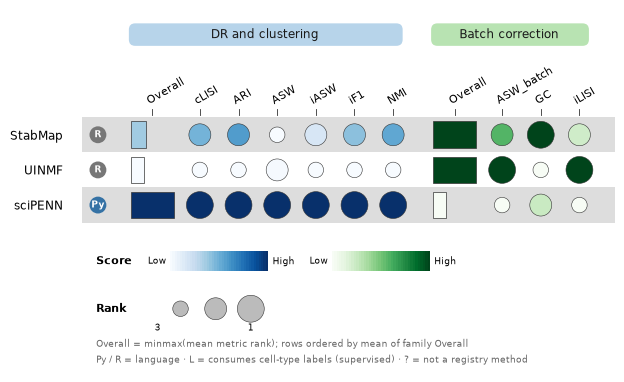

In [14]:
mine.plot()

## 4. Stored results

The package ships stored results for 8 methods on `D52` (`source="rerun"`). `load_results` reads them as a long table and `mtb.plot.bubble` draws it; nothing is run.

<details>
<summary>Details: sources</summary>

**Two sources.** For `D52`, the `published` table holds 1 method and the package's own runs (`"rerun"`) hold 8. `load_results` defaults to `source="published"`, so every call here names its source. Where both hold a method, the values can differ.

**Your own runs.** `run_all` saves its results in `out_dir`; `mtb.load_batch(out_dir)` reloads them later without running anything.

</details>

8 methods, ['rerun']


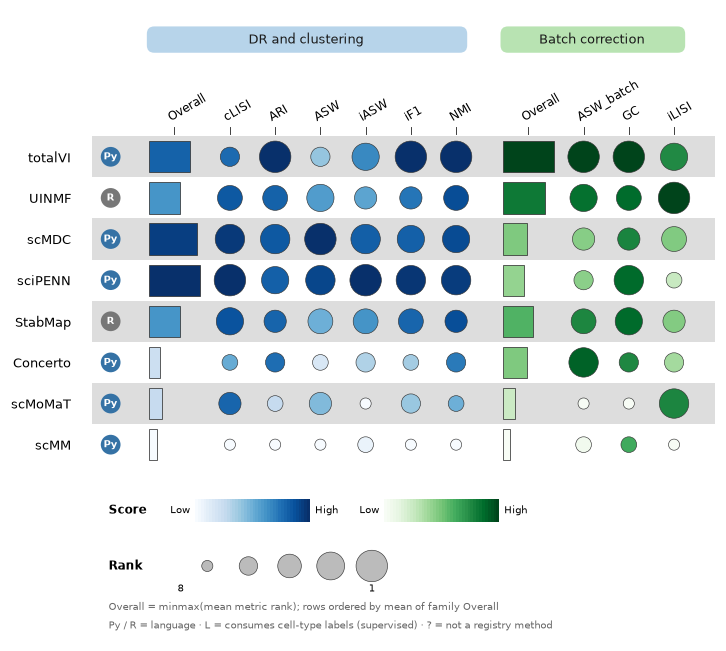

In [15]:
long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")
print(long.method.nunique(), "methods,", long.source.unique())
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

**Across datasets.** `aggregate="summary"` ranks the methods over `D52` and `D52s`, a 60% cell subsample of `D52`; `require_complete=True` keeps only the methods with results on both.

<details>
<summary>Details: summary bars</summary>

**Bars.** Each metric bar is the method's rank averaged over the datasets, min-max scaled; `Overall` summarises the family's metric ranks. Bar length and colour both show the value.

**Missing methods.** Without `require_complete=True`, a method absent from a dataset gets the lowest rank there, which pulls its bars down.

</details>

{'D52': 8, 'D52s': 8}


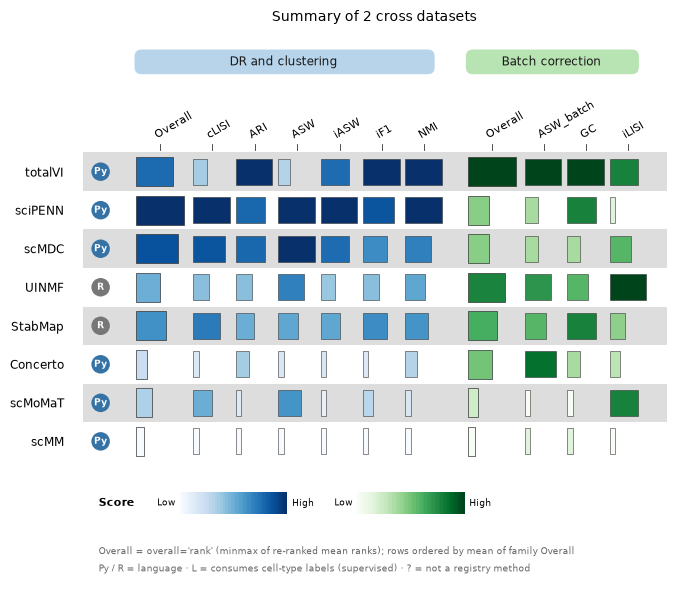

In [16]:
pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")
print(pair.groupby("dataset").method.nunique().to_dict())
mtb.plot.bubble(pair, aggregate="summary", require_complete=True,
                title=f"Summary of 2 cross datasets")

`results_coverage` counts the methods each stored source holds for this dataset:

In [17]:
cov = mtb.results_coverage(CATEGORY)
cov[cov.dataset == DATASET].groupby("source").method.nunique()

source
published    1
rerun        8
Name: method, dtype: int64

## 5. Reference

### What runs on a dataset, and why not

`scan` on `D52`, nothing run: the first table lists the variants whose data fits, with the install command for any missing environment (`env_reason`); the second, why the other variants do not fit.

<details>
<summary>Details</summary>

**From the shell.** `multibench scan D52 --category cross` prints the scan for every variant; `--columns all` adds every column, including `command`, the exact command `run` would execute.

</details>

In [18]:
avail = mtb.scan(DATASET, category=CATEGORY)
print(f"files_ok {int(avail.files_ok.sum())}, env_ok {int(avail.env_ok.sum())}, runnable {int(avail.runnable.sum())} of {len(avail)} method variants")
avail[avail.files_ok][["method", "modalities", "env", "env_ok", "env_reason",
                       "output_kind", "needs_labels", "runtime_tier"]]

[scan] files OK for 8/8 method rows; 0/8 envs installed


files_ok 8, env_ok 0, runnable 0 of 8 method variants


,method,modalities,env,env_ok,env_reason,output_kind,needs_labels,runtime_tier
0,Concerto,rna1+rna2+rna3+adt1+adt2+adt3,scmb_concerto,False,conda env 'scmb_concerto' is not installed - run `multibench env install --methods Concerto --packed --run` (or --category cross); see mtb.env.doctor(),embedding,False,very_slow
1,StabMap,rna1+rna2+rna3+adt1+adt2+adt3,scmb_r,False,conda env 'scmb_r' is not installed - run `multibench env install --methods StabMap --packed --run` (or --category cross); see mtb.env.doctor(),embedding,False,fast
2,UINMF,rna1+rna2+adt1+adt2,scmb_r,False,conda env 'scmb_r' is not installed - run `multibench env install --methods UINMF --packed --run` (or --category cross); see mtb.env.doctor(),embedding,False,fast
3,scMDC,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scmdc,False,conda env 'scmb_scmdc' is not installed - run `multibench env install --methods scMDC --packed --run` (or --category cross); see mtb.env.doctor(),embedding,False,slow
4,scMM,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scmm2,False,conda env 'scmb_scmm2' is not installed - run `multibench env install --methods scMM --packed --run` (or --category cross); see mtb.env.doctor(),embedding,False,medium
5,scMoMaT,rna1+rna2+rna3+adt1+adt2+adt3,scmb_torch,False,conda env 'scmb_torch' is not installed - run `multibench env install --methods scMoMaT --packed --run` (or --category cross); see mtb.env.doctor(),graph,False,medium
6,sciPENN,rna1+rna2+rna3+adt1+adt2+adt3,env_sciPENN,False,conda env 'env_sciPENN' is not installed - run `multibench env install --methods sciPENN --packed --run` (or --category cross); see mtb.env.doctor(),embedding,False,fast
7,totalVI,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scvi,False,conda env 'scmb_scvi' is not installed - run `multibench env install --methods totalVI --packed --run` (or --category cross); see mtb.env.doctor(),embedding,False,slow


In [19]:
not_ok = avail[~avail.files_ok][["method", "modalities", "files_reason"]]
not_ok.head(5) if len(not_ok) else "(every method's inputs resolve on this dataset)"


"(every method's inputs resolve on this dataset)"

### Tuning

The table counts the hyperparameters each variant exposes. `mtb.params_for(method, CATEGORY, modalities)` lists them; `run_all(..., params={"Method": {"key": value}})` sets them.

<details>
<summary>Details</summary>

**None exposed.** Many upstream scripts set their hyperparameters in code; their variants accept no `params`.

**From the shell.** `multibench params METHOD` prints the table; `multibench run-all ... --param METHOD:KEY=VALUE` sets a value.

</details>

In [20]:
rows = [{"method": m, "modalities": "+".join(v["modalities"]) or "(data_dir)",
         "n_tunable": v["n_tunable"], "needs_labels": v["needs_labels"],
         "output_kind": v["output_kind"]}
        for m in sorted(mtb.list_methods(category=CATEGORY))
        for v in mtb.method_info(m)["supports"] if v["category"] == CATEGORY]
pd.DataFrame(rows).sort_values(["n_tunable", "method"], ascending=[False, True]).reset_index(drop=True)

,method,modalities,n_tunable,needs_labels,output_kind
0,scMDC,rna1+rna2+rna3+adt1+adt2+adt3,24,False,embedding
1,scMM,rna1+rna2+rna3+adt1+adt2+adt3,19,False,embedding
2,sciPENN,rna1+rna2+rna3+adt1+adt2+adt3,1,False,embedding
3,Concerto,rna1+rna2+rna3+adt1+adt2+adt3,0,False,embedding
4,StabMap,rna1+rna2+rna3+adt1+adt2+adt3,0,False,embedding
5,UINMF,rna1+rna2+adt1+adt2,0,False,embedding
6,scMoMaT,rna1+rna2+rna3+adt1+adt2+adt3,0,False,graph
7,totalVI,rna1+rna2+rna3+adt1+adt2+adt3,0,False,embedding


### A method's record and citation

`method_info` returns what the registry holds about a method, including its reference and repository; `mtb.cite` returns the citations for the benchmark and the methods you ran.

<details>
<summary>Details</summary>

**needs_labels** is True when any variant needs cell-type labels; each entry of `supports` gives it per variant.

**verbose=True** adds the long notes.

</details>

In [21]:
info = mtb.method_info("StabMap", verbose=True)
{k: info[k] for k in ("id", "env", "needs_labels", "atac", "notes", "repo_url", "version", "reference")}

{'id': 'StabMap',
 'env': 'scmb_r',
 'needs_labels': False,
 'atac': 'peak',
 'notes': 'Mosaic integration by stabilised mapping onto a reference embedding using shared and unshared features; R, source()d through engine/drivers/run_stabmap.R.',
 'repo_url': 'https://github.com/MarioniLab/StabMap',
 'version': '0.1.8',
 'reference': {'doi': '10.1038/s41587-023-01766-z',
  'title': 'Stabilized mosaic single-cell data integration using unshared features',
  'authors': 'Ghazanfar S, Guibentif C, Marioni JC',
  'journal': 'Nature Biotechnology',
  'year': 2024}}

In [22]:
print(mtb.cite(['UINMF', 'sciPENN', 'StabMap']))   # fmt="bibtex" for BibTeX entries

Liu C, Ding S, Kim HJ, Long S, Xiao D, Ghazanfar S, Yang P. Multitask benchmarking of single-cell multimodal omics integration methods. Nature Methods (2025). https://doi.org/10.1038/s41592-025-02856-3
Kriebel AR, Welch JD. UINMF performs mosaic integration of single-cell multi-omic datasets using nonnegative matrix factorization. Nature Communications (2022). https://doi.org/10.1038/s41467-022-28431-4
Lakkis J, Schroeder A, Su K, Lee MYY, Bashore AC, Reilly MP, Li M. A multi-use deep learning method for CITE-seq and single-cell RNA-seq data integration with cell surface protein prediction and imputation. Nature Machine Intelligence (2022). https://doi.org/10.1038/s42256-022-00545-w
Ghazanfar S, Guibentif C, Marioni JC. Stabilized mosaic single-cell data integration using unshared features. Nature Biotechnology (2024). https://doi.org/10.1038/s41587-023-01766-z


### The metrics

Two families; higher is better for every metric.

| family | metrics | measures |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | whether the embedding separates the annotated cell types |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | whether the batches mix within each cell type |

<details>
<summary>Details</summary>

**Range.** All lie in [0, 1] except ARI, which can be slightly negative.

**Batch metrics** appear only when the dataset has more than one batch.

**kBET** is computed only when named (`metrics=["ASW_batch", "GC", "iLISI", "kBET"]`); it is much slower than the others.

</details>

### Methods from the benchmark study

The cell compares the methods the scMultiBench study benchmarked for cross integration with the methods this package has a cross variant for, and prints each missing method with the categories it has variants for.

In [23]:
paper = ['totalVI', 'scMoMaT', 'UnitedNet', 'sciPENN', 'Concerto', 'scMDC', 'StabMap', 'UINMF', 'scMM', 'MOFA2', 'Multigrate']   # benchmarked for cross on the tasks this package covers
registry = set(mtb.list_methods())
wired = sorted(m for m in registry
               if any(v["category"] == CATEGORY for v in mtb.method_info(m)["supports"]))
missing = [m for m in paper if m not in wired]
print(f"the study benchmarks {len(paper)} methods for {CATEGORY} on the tasks this package covers; this package has a variant for {len(wired)}")
for m in missing:
    if m in registry:
        info = mtb.method_info(m)
        print(f"  {m}: variants for {', '.join(info['categories'])} only (tasks: {', '.join(info['tasks'])})")
    else:
        print(f"  {m}: not in the registry")
if not missing:
    print("every benchmarked method has a variant for this category")

the study benchmarks 11 methods for cross on the tasks this package covers; this package has a variant for 8
  UnitedNet: variants for vertical only (tasks: clustering, classification)
  MOFA2: variants for vertical only (tasks: clustering)
  Multigrate: variants for mosaic, vertical only (tasks: clustering, batch)


## Troubleshooting

When a method is not runnable, `scan`'s `reason` column says why; when a run fails, `res.failures` holds the error.

<details>
<summary>Details</summary>

| symptom | fix |
|---|---|
| `files_ok` False: input files not found | the reason names the missing file and lists what the folder holds |
| `env_ok` False | run the `multibench env install ...` command in the reason |
| `... which is cells x features` | the matrix is transposed: re-export with `mtb.io.to_canonical` or `export_dataset` |
| a method fails | `res.failures.iloc[0]["error"]` ends with the method's stderr |
| a method times out | raise `timeout=` in `run_all` |
| low `label_order_confidence` | several label files fit the cell count: check `label_order_candidates` in `res.results` |
| batch metrics use the wrong batches | `res.rescore(batch=my_vector)` re-scores without re-running |

</details>

## Next steps

- the other tutorials: **vertical**, **diagonal**, **mosaic**
- the [interactive explorer](https://shiny.maths.usyd.edu.au/scMultiBench/): the full benchmark's rankings, no install needed
- `mtb.recommend(CATEGORY, modalities=[...])`: a ranking of methods from the stored results
- `mtb.sweep(...)`: one method over a range of values of one hyperparameter